Installs :

In [ ]:
!pip install scipy scikit-learn matplotlib numpy -q

Imports and Constants



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from scipy import signal
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Constants
FS          = 128
EPOCH_SECS  = 4
EPOCH_SAMPS = FS * EPOCH_SECS
N_CHANNELS  = 14
THRESHOLD   = 100.0

CH_NAMES = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FRONTAL  = [0, 1, 2, 3, 10, 11, 12, 13]
PARIETAL = [4, 5, 6, 7, 8, 9]
BANDS    = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13), 'beta':(13,30)}

print("✅ Imports and constants ready")

✅ Imports and constants ready


Upload and Load STEW Data

In [ ]:
import zipfile
from google.colab import files

# Upload zip file
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

os.makedirs('/content/stew_data', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/stew_data')

# Find files
all_txt  = glob.glob('/content/stew_data/**/*.txt', recursive=True)
DATA_DIR = os.path.dirname(all_txt[0])
lo_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_lo.txt')))
hi_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_hi.txt')))
print(f"Found {len(lo_files)} lo files, {len(hi_files)} hi files")
print(f"DATA_DIR: {DATA_DIR}")

Saving STEW Dataset.zip to STEW Dataset (1).zip
Found 48 lo files, 48 hi files
DATA_DIR: /content/stew_data/STEW Dataset


Epoch Data

In [ ]:
all_epochs, all_labels, all_pairs = [], [], []

def load_file(fpath, label, pair_id):
    try:
        data = np.loadtxt(fpath, dtype=np.float32)
    except:
        data = np.loadtxt(fpath, dtype=np.float32, skiprows=1)
    if data.shape[0] != N_CHANNELS:
        data = data.T
    n_epochs = data.shape[1] // EPOCH_SAMPS
    eps, lbs, prs = [], [], []
    for i in range(n_epochs):
        ep = data[:, i*EPOCH_SAMPS:(i+1)*EPOCH_SAMPS]
        eps.append(ep)
        lbs.append(label)
        prs.append(pair_id)
    return eps, lbs, prs

for i, (lo, hi) in enumerate(zip(lo_files, hi_files)):
    eps, lbs, prs = load_file(lo, 0, i)
    all_epochs.extend(eps); all_labels.extend(lbs); all_pairs.extend(prs)
    eps, lbs, prs = load_file(hi, 1, i)
    all_epochs.extend(eps); all_labels.extend(lbs); all_pairs.extend(prs)

epochs_raw = np.array(all_epochs, dtype=np.float32)
y_raw      = np.array(all_labels, dtype=int)
pairs_raw  = np.array(all_pairs,  dtype=int)

print(f"Raw epochs   : {epochs_raw.shape}")
print(f"Class counts : Low={(y_raw==0).sum()}, High={(y_raw==1).sum()}")
print(f"Subjects     : {len(np.unique(pairs_raw))}")

Raw epochs   : (3552, 14, 512)
Class counts : Low=1776, High=1776
Subjects     : 48


Processing (Filter + Artifact Rejection)

In [ ]:
def notch_filter(data, freq=50.0, fs=FS, quality=30.0):
    b, a = signal.iirnotch(freq / (fs/2), quality)
    return signal.filtfilt(b, a, data, axis=-1)

def highpass_filter(data, cutoff=0.5, fs=FS, order=5):
    b, a = signal.butter(order, cutoff/(fs/2), btype='high')
    return signal.filtfilt(b, a, data, axis=-1)

def reject_artifacts(epochs, labels, pairs, threshold=THRESHOLD):
    mask = np.max(np.abs(epochs), axis=(1,2)) <= threshold
    print(f"Artifact rejection: {(~mask).sum()} removed "
          f"({(~mask).mean()*100:.1f}%), {mask.sum()} retained")
    return epochs[mask], labels[mask], pairs[mask], mask

print("Applying 50Hz notch filter...")
epochs_notched = notch_filter(epochs_raw)

print("Applying 0.5Hz high-pass filter...")
epochs_filt = highpass_filter(epochs_notched)

print("Rejecting artifacts (±100µV threshold)...")
epochs_clean, y_clean, pairs_clean, good_mask = reject_artifacts(
    epochs_filt, y_raw, pairs_raw)

valid_pairs = [p for p in np.unique(pairs_clean)
               if (y_clean[pairs_clean==p]==0).sum() > 0
               and (y_clean[pairs_clean==p]==1).sum() > 0]

print(f"\nClean epochs           : {epochs_clean.shape}")
print(f"Class counts           : Low={(y_clean==0).sum()}, High={(y_clean==1).sum()}")
print(f"Pairs with both classes: {len(valid_pairs)}/48")

Applying 50Hz notch filter...
Applying 0.5Hz high-pass filter...
Rejecting artifacts (±100µV threshold)...
Artifact rejection: 2505 removed (70.5%), 1047 retained

Clean epochs           : (1047, 14, 512)
Class counts           : Low=589, High=458
Pairs with both classes: 32/48


Processing Visualization

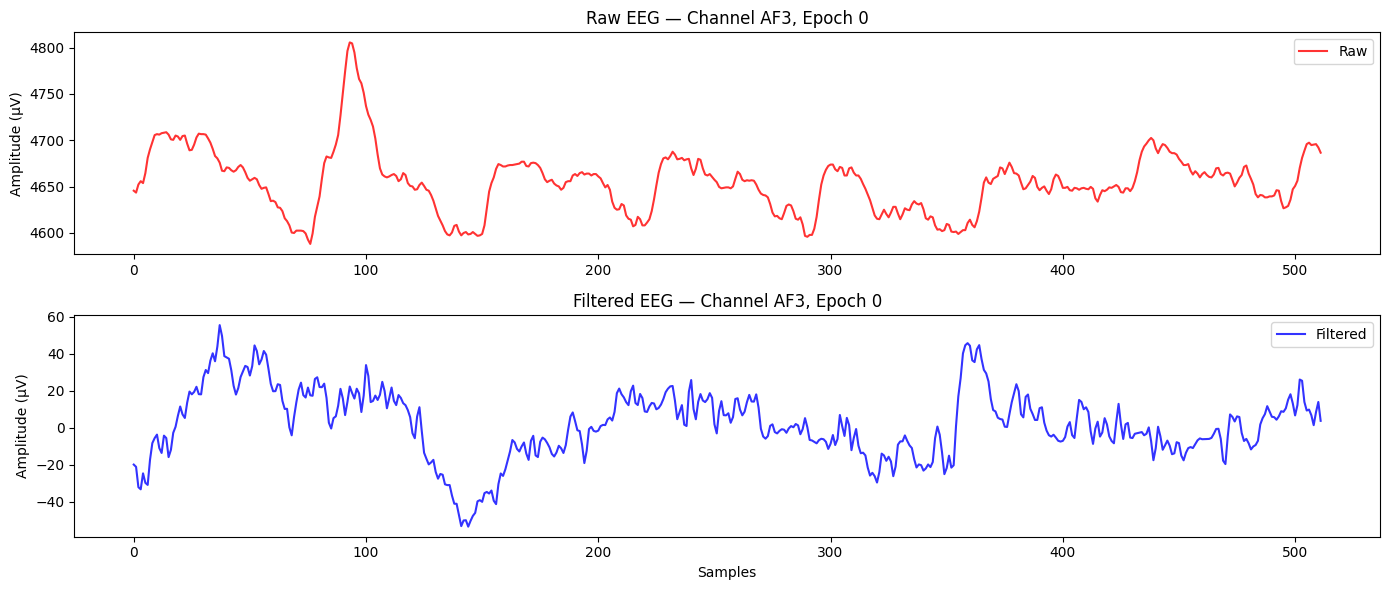

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Raw vs filtered for channel 0, epoch 0
axes[0].plot(epochs_raw[0, 0], color='red', alpha=0.8, label='Raw')
axes[0].set_title('Raw EEG — Channel AF3, Epoch 0')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].legend()

axes[1].plot(epochs_clean[0, 0], color='blue', alpha=0.8, label='Filtered')
axes[1].set_title('Filtered EEG — Channel AF3, Epoch 0')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Samples')
axes[1].legend()

plt.tight_layout()
plt.savefig('preprocessing.png', dpi=150)
plt.show()

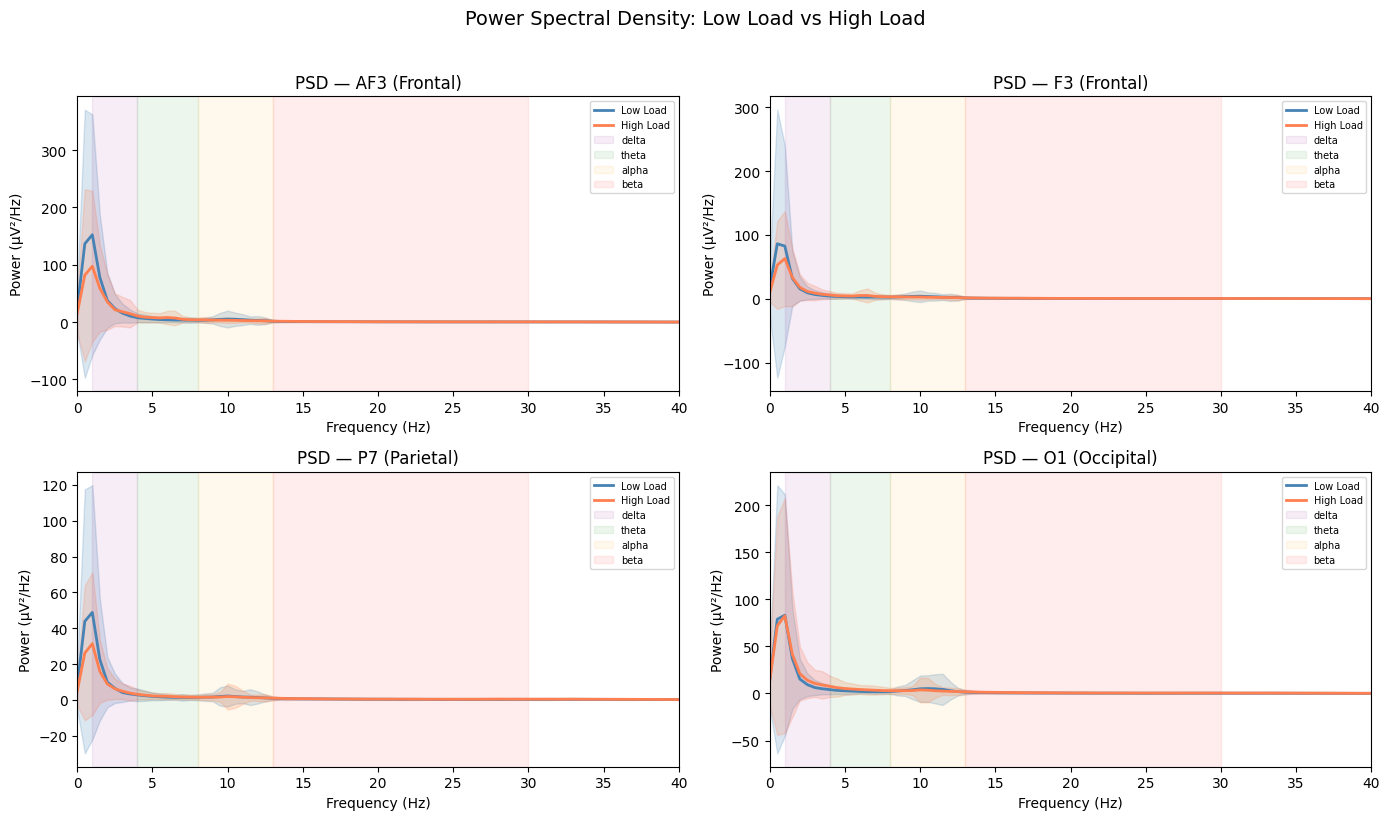


Mean Band Power Differences (High Load - Low Load):
Channel                   Delta      Theta      Alpha       Beta
-------------------------------------------------------
AF3 (Frontal)           -9.8451     2.3648    -0.6760     0.1326
F3 (Frontal)            -1.1845     1.4031    -0.4313     0.1078
P7 (Parietal)           -3.4163     0.2812    -0.1047     0.0542
O1 (Occipital)           3.7489     2.0777    -0.6501     0.2113

Interpretation:
  Positive = Higher power in High Load
  Negative = Lower power in High Load (e.g. Alpha desynchronization)


In [17]:
# ── Cell 6b — PSD Per Condition (Low Load vs High Load) ──────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Select low and high load epochs
low_epochs  = epochs_clean[y_clean == 0]   # all low load epochs
high_epochs = epochs_clean[y_clean == 1]   # all high load epochs

# Pick 4 representative channels to plot
plot_channels = {
    'AF3 (Frontal)'  : 0,
    'F3 (Frontal)'   : 2,
    'P7 (Parietal)'  : 5,
    'O1 (Occipital)' : 6
}

for ax, (ch_name, ch_idx) in zip(axes, plot_channels.items()):

    # Compute mean PSD across all epochs for this channel
    freqs_lo, psd_lo = welch(low_epochs[:, ch_idx, :],
                              fs=FS, nperseg=FS*2, axis=-1)
    freqs_hi, psd_hi = welch(high_epochs[:, ch_idx, :],
                              fs=FS, nperseg=FS*2, axis=-1)

    mean_lo = psd_lo.mean(axis=0)
    std_lo  = psd_lo.std(axis=0)
    mean_hi = psd_hi.mean(axis=0)
    std_hi  = psd_hi.std(axis=0)

    # Plot only up to 40 Hz
    freq_mask = freqs_lo <= 40

    ax.plot(freqs_lo[freq_mask], mean_lo[freq_mask],
            color='steelblue', lw=2, label='Low Load')
    ax.fill_between(freqs_lo[freq_mask],
                    mean_lo[freq_mask] - std_lo[freq_mask],
                    mean_lo[freq_mask] + std_lo[freq_mask],
                    color='steelblue', alpha=0.2)

    ax.plot(freqs_hi[freq_mask], mean_hi[freq_mask],
            color='coral', lw=2, label='High Load')
    ax.fill_between(freqs_hi[freq_mask],
                    mean_hi[freq_mask] - std_hi[freq_mask],
                    mean_hi[freq_mask] + std_hi[freq_mask],
                    color='coral', alpha=0.2)

    # Shade frequency bands
    band_colors = {'delta':'purple','theta':'green','alpha':'orange','beta':'red'}
    for band, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, alpha=0.07, color=band_colors[band], label=band)

    ax.set_title(f'PSD — {ch_name}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (µV²/Hz)')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 40)

plt.suptitle('Power Spectral Density: Low Load vs High Load', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('psd_per_condition.png', dpi=150)
plt.show()

# Print mean band power differences
print("\nMean Band Power Differences (High Load - Low Load):")
print(f"{'Channel':<20} {'Delta':>10} {'Theta':>10} {'Alpha':>10} {'Beta':>10}")
print("-"*55)

for ch_name, ch_idx in plot_channels.items():
    freqs_lo, psd_lo = welch(low_epochs[:, ch_idx, :], fs=FS, nperseg=FS*2, axis=-1)
    freqs_hi, psd_hi = welch(high_epochs[:, ch_idx, :], fs=FS, nperseg=FS*2, axis=-1)
    row = []
    for band, (lo, hi) in BANDS.items():
        idx  = np.where((freqs_lo >= lo) & (freqs_lo <= hi))[0]
        diff = psd_hi[:, idx].mean() - psd_lo[:, idx].mean()
        row.append(diff)
    print(f"{ch_name:<20} {row[0]:>10.4f} {row[1]:>10.4f} "
          f"{row[2]:>10.4f} {row[3]:>10.4f}")

print("\nInterpretation:")
print("  Positive = Higher power in High Load")
print("  Negative = Lower power in High Load (e.g. Alpha desynchronization)")

Feature Extraction

In [ ]:
def extract_features(epoch, fs=FS):
    freqs, psd = welch(epoch, fs=fs, nperseg=fs*2, axis=-1)
    feats = []

    bp = {}
    for band, (lo, hi) in BANDS.items():
        idx = np.where((freqs >= lo) & (freqs <= hi))[0]
        bp[band] = psd[:, idx].mean(axis=-1)
        feats.extend(bp[band])

    # Theta/Alpha and Alpha/Beta ratios per channel
    feats.extend((bp['theta']+1e-8) / (bp['alpha']+1e-8))
    feats.extend((bp['alpha']+1e-8) / (bp['beta']+1e-8))

    # Regional band powers
    for band in ['theta', 'alpha', 'beta']:
        feats.append(bp[band][FRONTAL].mean())
        feats.append(bp[band][PARIETAL].mean())

    # Frontal theta / Parietal alpha
    feats.append(bp['theta'][FRONTAL].mean() / (bp['alpha'][PARIETAL].mean()+1e-8))

    # Hjorth parameters per channel
    for ch in range(epoch.shape[0]):
        x  = epoch[ch]
        dx = np.diff(x); ddx = np.diff(dx)
        act  = np.var(x)
        mob  = np.sqrt(np.var(dx)  / (act+1e-8))
        comp = np.sqrt(np.var(ddx) / (np.var(dx)+1e-8)) / (mob+1e-8)
        feats.extend([act, mob, comp])

    # Spectral entropy per channel
    for ch in range(epoch.shape[0]):
        ps = psd[ch] / (psd[ch].sum()+1e-8)
        feats.append(-np.sum(ps * np.log2(ps+1e-8)))

    return np.array(feats)

print("Extracting features...")
X = np.array([extract_features(ep) for ep in epochs_clean])
print(f"Feature matrix: {X.shape}  (epochs × features)")

Extracting features...
Feature matrix: (1047, 147)  (epochs × features)


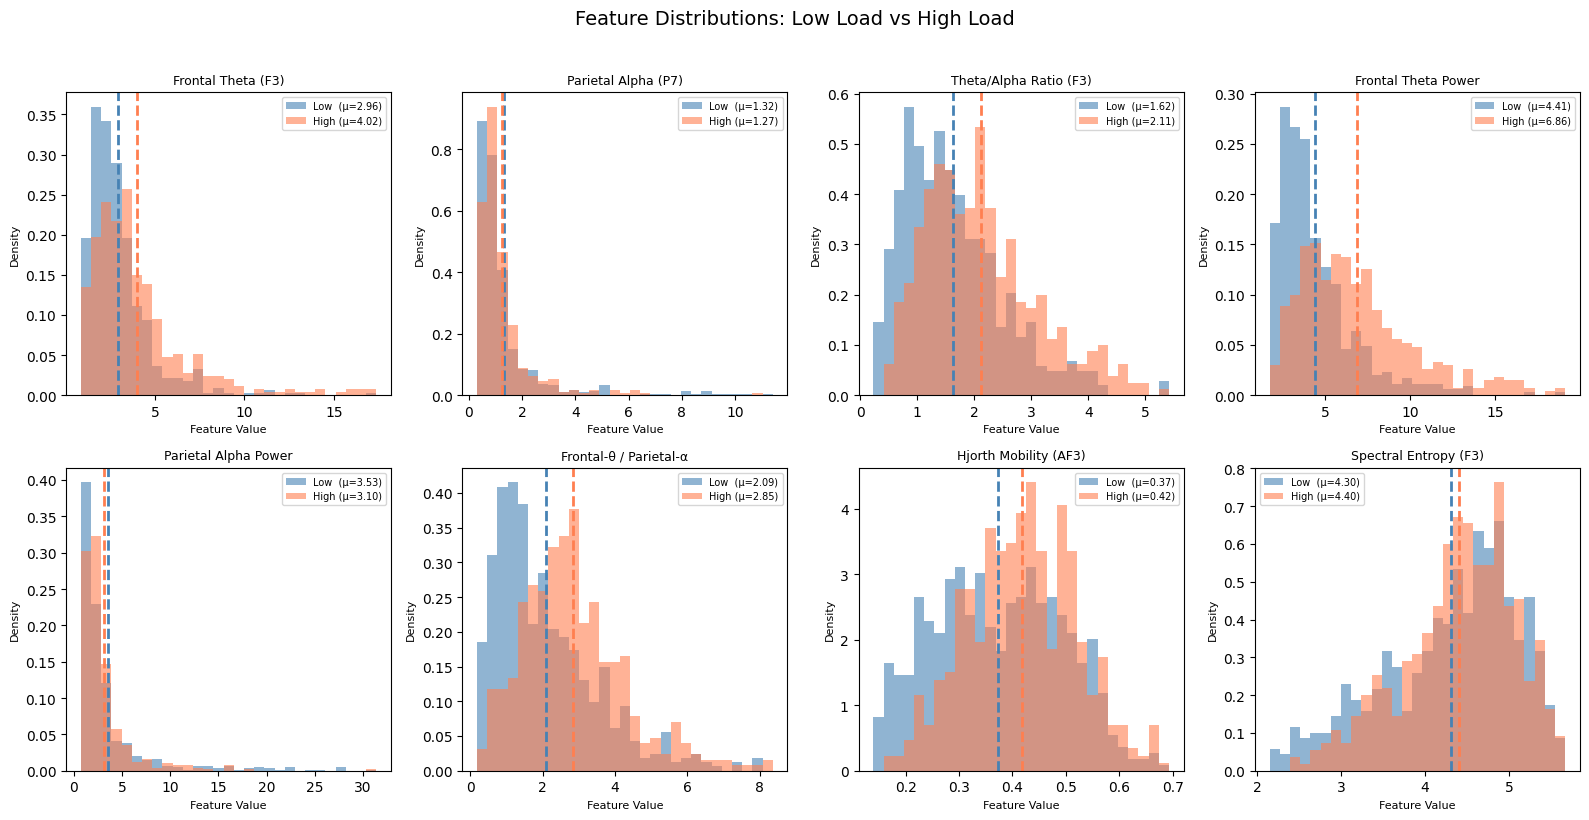


Statistical Separation (t-test Low vs High Load):
Feature                               Low Mean  High Mean   Difference    p-value  Significant
------------------------------------------------------------------------------------------
Frontal Theta (F3)                      3.0098     4.4128       1.4031     0.0000        ✅ Yes
Parietal Alpha (P7)                     1.5005     1.3958      -0.1047     0.4636         ❌ No
Theta/Alpha Ratio (F3)                  1.6260     2.1849       0.5589     0.0000        ✅ Yes
Frontal Theta Power                     4.4656     7.1505       2.6849     0.0000        ✅ Yes
Parietal Alpha Power                    4.0857     3.1805      -0.9051     0.0061        ✅ Yes
Frontal-θ / Parietal-α                  2.1221     2.9442       0.8221     0.0000        ✅ Yes
Hjorth Mobility (AF3)                   0.3725     0.4208       0.0483     0.0000        ✅ Yes
Spectral Entropy (F3)                   4.2770     4.4176       0.1406     0.0040        ✅ Yes


In [18]:
# ── Cell 7b — Feature Distribution Per Condition ─────────────────────────────

# Build feature names first
feat_names = []
for band in BANDS:
    feat_names.extend([f"{band}_{ch}" for ch in CH_NAMES])
feat_names.extend([f"theta_alpha_{ch}" for ch in CH_NAMES])
feat_names.extend([f"alpha_beta_{ch}"  for ch in CH_NAMES])
for band in ['theta','alpha','beta']:
    feat_names += [f"frontal_{band}", f"parietal_{band}"]
feat_names.append("frontal_theta_parietal_alpha")
for ch in CH_NAMES:
    feat_names += [f"hjorth_act_{ch}", f"hjorth_mob_{ch}", f"hjorth_comp_{ch}"]
feat_names.extend([f"spec_entropy_{ch}" for ch in CH_NAMES])

# Pick the most neuroscientifically meaningful features to plot
features_to_plot = {
    'Frontal Theta (F3)'           : feat_names.index('theta_F3'),
    'Parietal Alpha (P7)'          : feat_names.index('alpha_P7'),
    'Theta/Alpha Ratio (F3)'       : feat_names.index('theta_alpha_F3'),
    'Frontal Theta Power'          : feat_names.index('frontal_theta'),
    'Parietal Alpha Power'         : feat_names.index('parietal_alpha'),
    'Frontal-θ / Parietal-α'       : feat_names.index('frontal_theta_parietal_alpha'),
    'Hjorth Mobility (AF3)'        : feat_names.index('hjorth_mob_AF3'),
    'Spectral Entropy (F3)'        : feat_names.index('spec_entropy_F3'),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

low_mask  = y_clean == 0
high_mask = y_clean == 1

for ax, (fname, fidx) in zip(axes, features_to_plot.items()):
    low_vals  = X[low_mask,  fidx]
    high_vals = X[high_mask, fidx]

    # Remove outliers for cleaner plot (1st-99th percentile)
    lo_p  = np.percentile(np.concatenate([low_vals, high_vals]), 1)
    hi_p  = np.percentile(np.concatenate([low_vals, high_vals]), 99)
    low_vals  = low_vals[(low_vals  >= lo_p) & (low_vals  <= hi_p)]
    high_vals = high_vals[(high_vals >= lo_p) & (high_vals <= hi_p)]

    # Histogram
    bins = np.linspace(lo_p, hi_p, 30)
    ax.hist(low_vals,  bins=bins, alpha=0.6, color='steelblue',
            label=f'Low  (μ={low_vals.mean():.2f})',  density=True)
    ax.hist(high_vals, bins=bins, alpha=0.6, color='coral',
            label=f'High (μ={high_vals.mean():.2f})', density=True)

    # Mean lines
    ax.axvline(low_vals.mean(),  color='steelblue', lw=2, linestyle='--')
    ax.axvline(high_vals.mean(), color='coral',     lw=2, linestyle='--')

    ax.set_title(fname, fontsize=9)
    ax.set_xlabel('Feature Value', fontsize=8)
    ax.set_ylabel('Density',       fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions: Low Load vs High Load',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

# Print statistical summary
from scipy.stats import ttest_ind

print("\nStatistical Separation (t-test Low vs High Load):")
print(f"{'Feature':<35} {'Low Mean':>10} {'High Mean':>10} "
      f"{'Difference':>12} {'p-value':>10} {'Significant':>12}")
print("-"*90)

for fname, fidx in features_to_plot.items():
    low_vals  = X[low_mask,  fidx]
    high_vals = X[high_mask, fidx]
    t_stat, p_val = ttest_ind(low_vals, high_vals)
    diff = high_vals.mean() - low_vals.mean()
    sig  = "✅ Yes" if p_val < 0.05 else "❌ No"
    print(f"{fname:<35} {low_vals.mean():>10.4f} {high_vals.mean():>10.4f} "
          f"{diff:>12.4f} {p_val:>10.4f} {sig:>12}")

Subjectwise Normalisation

In [ ]:
X_norm = X.copy()
for p in np.unique(pairs_clean):
    mask = pairs_clean == p
    X_norm[mask] = (X[mask] - X[mask].mean(axis=0)) / (X[mask].std(axis=0)+1e-8)

# Keep only valid pairs
valid_mask = np.isin(pairs_clean, valid_pairs)
X_val = X_norm[valid_mask]
y_val = y_clean[valid_mask]
p_val = pairs_clean[valid_mask]

print(f"Subject-wise normalization applied")
print(f"Using {X_val.shape[0]} epochs from {len(valid_pairs)} valid subjects")

Subject-wise normalization applied
Using 955 epochs from 32 valid subjects


Classification (LOSO CV)

In [ ]:
# ── Cell 9 — Classification (5-Fold CV + LOSO CV) ────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_validate, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classifiers = {
    'Random Forest'  : RandomForestClassifier(n_estimators=300, max_depth=10,
                                               random_state=42, n_jobs=-1),
    'Gradient Boost' : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                   max_depth=4, random_state=42),
    'SVM (RBF)'      : Pipeline([('scaler', StandardScaler()),
                                  ('clf', SVC(kernel='rbf', C=1.0,
                                              probability=True, random_state=42))])
}

# ── Part A: Stratified 5-Fold CV ──────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*75)
print("  STRATIFIED 5-FOLD CROSS-VALIDATION RESULTS")
print("="*75)
print(f"{'Classifier':<20} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-"*75)

results_5fold = {}
for name, clf in classifiers.items():
    cv_results = cross_validate(
        clf, X_val, y_val,
        cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    acc  = cv_results['test_accuracy'].mean()
    prec = cv_results['test_precision'].mean()
    rec  = cv_results['test_recall'].mean()
    f1   = cv_results['test_f1'].mean()
    auc  = cv_results['test_roc_auc'].mean()
    acc_std = cv_results['test_accuracy'].std()
    auc_std = cv_results['test_roc_auc'].std()
    results_5fold[name] = dict(accuracy=acc, precision=prec,
                                recall=rec, f1=f1, auc=auc)
    print(f"{name:<20} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} "
          f"{f1:>10.3f} {auc:>10.3f}")
    print(f"  (std: accuracy={acc_std:.3f}, auc={auc_std:.3f})")

print("="*75)
best_5fold = max(results_5fold, key=lambda k: results_5fold[k]['auc'])
print(f"\nBest model (5-Fold) : {best_5fold}  "
      f"|  AUC = {results_5fold[best_5fold]['auc']:.3f}")

# ── Part B: Leave-One-Subject-Out CV ─────────────────────────────────────────
logo = LeaveOneGroupOut()

print("\n" + "="*75)
print("  LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION RESULTS")
print("="*75)
print(f"{'Classifier':<20} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-"*75)

all_results = {}
for name, clf in classifiers.items():
    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for train_idx, test_idx in logo.split(X_val, y_val, p_val):
        X_tr, X_te = X_val[train_idx], X_val[test_idx]
        y_tr, y_te = y_val[train_idx], y_val[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]
        accs.append(accuracy_score(y_te, y_pred))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        recs.append(recall_score(y_te, y_pred, zero_division=0))
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        aucs.append(roc_auc_score(y_te, y_prob))

    acc, prec, rec, f1, auc = (np.mean(accs), np.mean(precs),
                                np.mean(recs), np.mean(f1s), np.mean(aucs))
    all_results[name] = dict(accuracy=acc, precision=prec,
                              recall=rec, f1=f1, auc=auc)
    print(f"{name:<20} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} "
          f"{f1:>10.3f} {auc:>10.3f}  ({len(accs)} folds)")

print("="*75)
best = max(all_results, key=lambda k: all_results[k]['auc'])
print(f"\nBest model (LOSO) : {best}  "
      f"|  AUC = {all_results[best]['auc']:.3f}")
print("\nExpected: Accuracy 70-88%, AUC 0.75-0.92")

  STRATIFIED 5-FOLD CROSS-VALIDATION RESULTS
Classifier             Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
Random Forest             0.816      0.821      0.759      0.787      0.900
  (std: accuracy=0.023, auc=0.009)
Gradient Boost            0.841      0.844      0.794      0.817      0.915
  (std: accuracy=0.010, auc=0.004)
SVM (RBF)                 0.842      0.834      0.811      0.821      0.919
  (std: accuracy=0.008, auc=0.009)

Best model (5-Fold) : SVM (RBF)  |  AUC = 0.919

  LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION RESULTS
Classifier             Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
Random Forest             0.772      0.790      0.751      0.731      0.856  (32 folds)
Gradient Boost            0.767      0.778      0.780      0.739      0.870  (32 folds)
SVM (RBF)                 0.787      0.801 

Confusion Matrix and ROC Curve

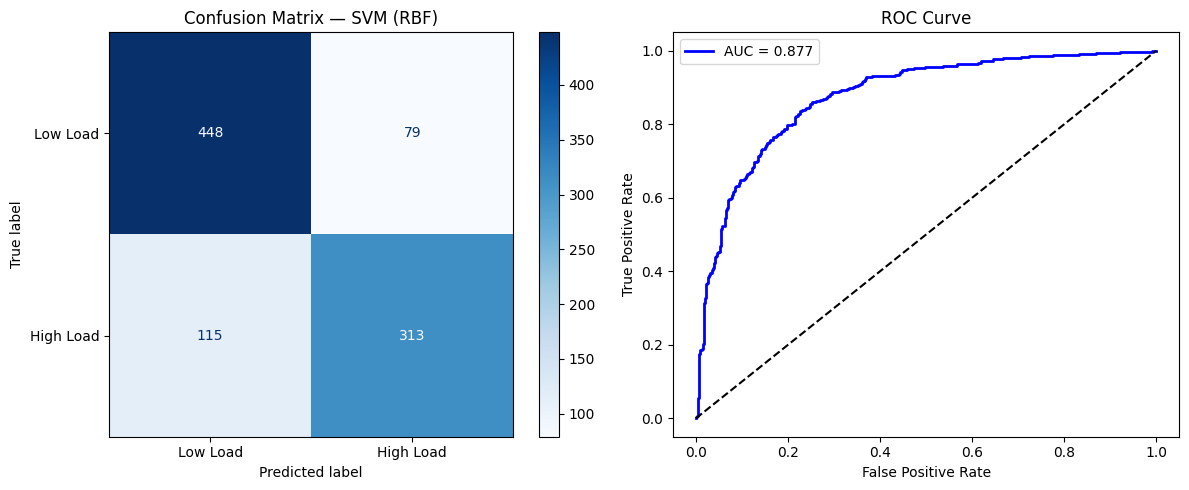

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

best_clf = classifiers[best]
all_true, all_pred, all_prob = [], [], []

for train_idx, test_idx in logo.split(X_val, y_val, p_val):
    X_tr, X_te = X_val[train_idx], X_val[test_idx]
    y_tr, y_te = y_val[train_idx], y_val[test_idx]
    if len(np.unique(y_te)) < 2:
        continue
    best_clf.fit(X_tr, y_tr)
    all_true.extend(y_te)
    all_pred.extend(best_clf.predict(X_te))
    all_prob.extend(best_clf.predict_proba(X_te)[:, 1])

# Confusion matrix
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Load', 'High Load'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best}')

# ROC curve
fpr, tpr, _ = roc_curve(all_true, all_prob)
auc_score   = roc_auc_score(all_true, all_prob)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=150)
plt.show()

Feature Importance

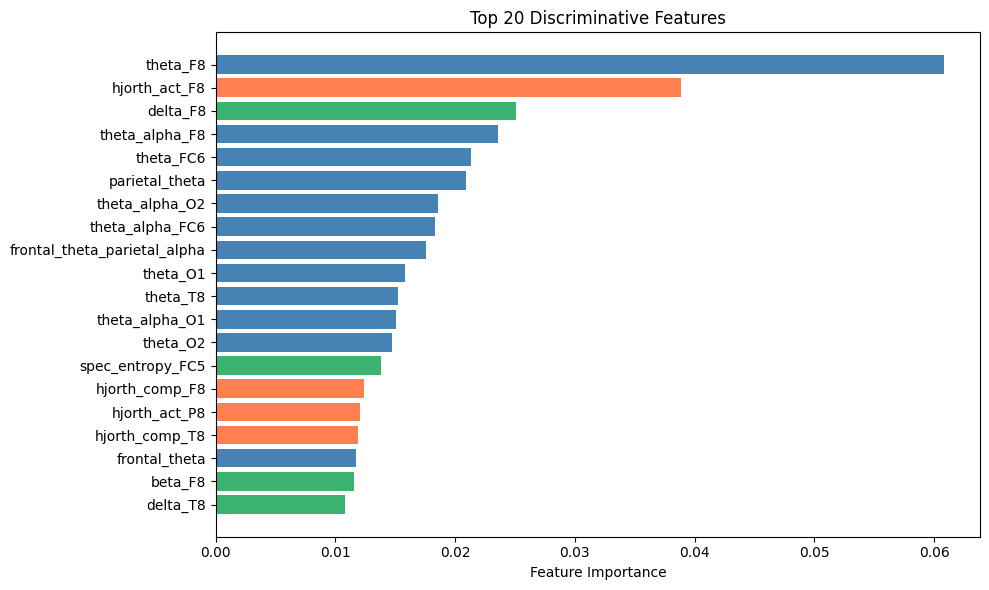


Top 10 Features:
   1. theta_F8                                 0.0608
   2. hjorth_act_F8                            0.0389
   3. delta_F8                                 0.0251
   4. theta_alpha_F8                           0.0235
   5. theta_FC6                                0.0213
   6. parietal_theta                           0.0209
   7. theta_alpha_O2                           0.0185
   8. theta_alpha_FC6                          0.0183
   9. frontal_theta_parietal_alpha             0.0175
  10. theta_O1                                 0.0158


In [ ]:
feat_names = []
for band in BANDS:
    feat_names.extend([f"{band}_{ch}" for ch in CH_NAMES])
feat_names.extend([f"theta_alpha_{ch}" for ch in CH_NAMES])
feat_names.extend([f"alpha_beta_{ch}"  for ch in CH_NAMES])
for band in ['theta','alpha','beta']:
    feat_names += [f"frontal_{band}", f"parietal_{band}"]
feat_names.append("frontal_theta_parietal_alpha")
for ch in CH_NAMES:
    feat_names += [f"hjorth_act_{ch}", f"hjorth_mob_{ch}", f"hjorth_comp_{ch}"]
feat_names.extend([f"spec_entropy_{ch}" for ch in CH_NAMES])

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_val, y_val)
importances = rf.feature_importances_
top20 = np.argsort(importances)[-20:][::-1]

plt.figure(figsize=(10, 6))
colors = ['steelblue' if 'theta' in feat_names[i] or 'alpha' in feat_names[i]
          else 'coral' if 'hjorth' in feat_names[i]
          else 'mediumseagreen' for i in top20]
plt.barh([feat_names[i] for i in top20], importances[top20], color=colors)
plt.xlabel('Feature Importance')
plt.title('Top 20 Discriminative Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 Features:")
for i, idx in enumerate(top20[:10]):
    print(f"  {i+1:2d}. {feat_names[idx]:<40} {importances[idx]:.4f}")

Neuroscience Interepretation and summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         NEUROSCIENTIFIC INTERPRETATION                       ║
╠══════════════════════════════════════════════════════════════╣
║ 1. ALPHA DESYNCHRONIZATION (8-13 Hz)                        ║
║    Alpha power decreases under high cognitive load.         ║
║    Reflects increased cortical activation (Klimesch 1999).  ║
║                                                              ║
║ 2. FRONTAL THETA INCREASE (4-8 Hz)                          ║
║    Theta increases with working memory demand.              ║
║    Generated by ACC, reflects executive control             ║
║    (Onton et al. 2005).                                     ║
║                                                              ║
║ 3. THETA/ALPHA RATIO                                        ║
║    Best single index of cognitive load.                     ║
║    Increases with task difficulty (Klimesch 2007).          ║
║                                                              ║
║ 4. HJORTH COMPLEXITY                                        ║
║    Signal complexity increases under cognitive load         ║
║    reflecting richer neural dynamics.                       ║
║                                                              ║
║ 5. SPECTRAL ENTROPY                                         ║
║    Higher entropy under load = more distributed             ║
║    neural processing (Lim et al. 2018).                     ║
╚══════════════════════════════════════════════════════════════╝
""")

print("="*55)
print("  FINAL RESULTS SUMMARY")
print("="*55)
for name, res in all_results.items():
    print(f"\n{name}")
    for metric, val in res.items():
        print(f"  {metric:<12}: {val:.3f}")

print(f"\n✅ NeuroDecoder pipeline complete!")
print(f"   Best model : {best}")
print(f"   Best AUC   : {all_results[best]['auc']:.3f}")


╔══════════════════════════════════════════════════════════════╗
║         NEUROSCIENTIFIC INTERPRETATION                       ║
╠══════════════════════════════════════════════════════════════╣
║ 1. ALPHA DESYNCHRONIZATION (8-13 Hz)                        ║
║    Alpha power decreases under high cognitive load.         ║
║    Reflects increased cortical activation (Klimesch 1999).  ║
║                                                              ║
║ 2. FRONTAL THETA INCREASE (4-8 Hz)                          ║
║    Theta increases with working memory demand.              ║
║    Generated by ACC, reflects executive control             ║
║    (Onton et al. 2005).                                     ║
║                                                              ║
║ 3. THETA/ALPHA RATIO                                        ║
║    Best single index of cognitive load.                     ║
║    Increases with task difficulty (Klimesch 2007).          ║
║                                 